# Survival Analysis: Primary Biliary Cirrhosis (PBC)

**Cox Proportional Hazard Model dengan Penanganan Pelanggaran Asumsi PH**

---

## Tujuan Penelitian
Mengidentifikasi faktor prognostik yang mempengaruhi survival pasien PBC menggunakan
Cox Proportional Hazard Model dengan tiga varian: Standard, Stratified, dan Extended Cox.

## Flow Chart

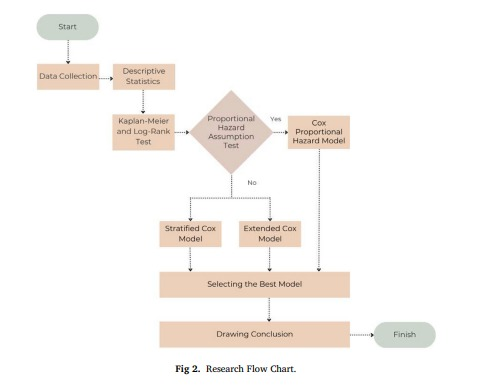

## Struktur Pipeline

1. **Configuration** - parameter penelitian terpusat
2. **Data Loading & Preprocessing** - load dataset, handle missing, encode event
3. **Descriptive Statistics** - karakteristik sampel
4. **Kaplan-Meier & Log-Rank Test** - analisis non-parametrik
5. **Standard Cox Model** - model baseline
6. **PH Assumption Test** - uji Schoenfeld residuals
7. **Stratified Cox Model** - alternatif 1 untuk PH violation
8. **Extended Cox Model** - alternatif 2 (time-varying coefficient)
9. **Model Comparison & Selection** - perbandingan multi-kriteria
10. **Final Interpretation** - hazard ratios dan kesimpulan
11. **Main Pipeline** - orkestrator end-to-end


## 1. Configuration

Semua parameter penelitian dikonsolidasikan dalam satu objek konfigurasi untuk
memastikan konsistensi di seluruh pipeline.


In [1]:
# ============================================================================
# CONFIGURATION
# ============================================================================
from dataclasses import dataclass, field
from typing import List, Optional


@dataclass
class PipelineConfig:
    """
    Konfigurasi terpusat untuk seluruh pipeline penelitian.

    Attributes
    ----------
    data_path : str
        Path ke file CSV dataset PBC
    duration_col : str
        Nama kolom durasi (waktu observasi)
    event_col : str
        Nama kolom event (1=event, 0=censored)
    covariates : list of str
        Variabel prediktor yang masuk ke model Cox
    ph_violating_var : str
        Variabel yang melanggar asumsi PH (digunakan untuk strata/extended)
    alpha : float
        Significance threshold untuk semua uji statistik
    random_seed : int
        Seed untuk reproducibility
    """
    data_path: str = "data\\Mayo Clinic Primary Biliary Cirrhosis Data.csv"
    duration_col: str = "time"
    event_col: str = "event"
    covariates: List[str] = field(
        default_factory=lambda: ["age", "bili", "albumin", "stage"]
    )
    ph_violating_var: str = "stage"
    alpha: float = 0.05
    random_seed: int = 42

    def __repr__(self) -> str:
        return (
            f"PipelineConfig("
            f"\n  data_path     = {self.data_path}"
            f"\n  duration_col  = {self.duration_col}"
            f"\n  event_col     = {self.event_col}"
            f"\n  covariates    = {self.covariates}"
            f"\n  alpha         = {self.alpha}"
            f"\n)"
        )


CONFIG = PipelineConfig()
print(CONFIG)


PipelineConfig(
  data_path     = data\Mayo Clinic Primary Biliary Cirrhosis Data.csv
  duration_col  = time
  event_col     = event
  covariates    = ['age', 'bili', 'albumin', 'stage']
  alpha         = 0.05
)


## 2. Imports & Environment Setup

In [2]:
# IMPORTS
import warnings
from typing import Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

from lifelines import (
    KaplanMeierFitter,
    CoxPHFitter,
    CoxTimeVaryingFitter,
)
from lifelines.statistics import (
    multivariate_logrank_test,
    proportional_hazard_test,
)

# Reproducibility & display
np.random.seed(CONFIG.random_seed)
warnings.filterwarnings("ignore")
pd.set_option("display.precision", 4)
pd.set_option("display.width", 120)

# Plotting defaults (clean, publication-quality)
plt.rcParams.update({
    "figure.figsize":     (10, 6),
    "figure.dpi":         100,
    "font.size":          11,
    "axes.titlesize":     12,
    "axes.titleweight":   "bold",
    "axes.labelsize":     10,
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.grid":          True,
    "grid.linestyle":     "--",
    "grid.alpha":         0.4,
    "legend.frameon":     False,
})

import lifelines
print(lifelines.__version__)


0.30.3


## 3. Stage 1: Data Loading & Preprocessing

**Keputusan preprocessing:**
- `status`: 0 (censored), 1 (transplant - censored), 2 (dead - event)
- `event` = 1 jika `status == 2`, lainnya 0
- `age`: sudah dalam tahun pada dataset ini (tidak perlu konversi)
- `stage`: numerik ordinal (1-4). Diperlakukan sebagai kontinu untuk parsimony
  (1 koefisien vs 3 dummy); asumsi log-linearitas terhadap stage
- Missing values: hanya 6 pada `stage` dari 418 (1.4%) - di-drop (MCAR plausibel)


In [3]:
# 1. DATA LOADING & PREPROCESSING

def load_and_preprocess(config: PipelineConfig) -> pd.DataFrame:
    """
    Load PBC dataset dan lakukan preprocessing.

    Returns
    -------
    pd.DataFrame
        DataFrame dengan kolom: [time, event, age, bili, albumin, stage]
        Tidak mengandung missing values pada kolom yang digunakan.

    Raises
    ------
    FileNotFoundError
        Jika data_path tidak valid.
    ValueError
        Jika kolom yang diharapkan tidak ada di dataset.
    """
    df_raw = pd.read_csv(config.data_path)

    required_cols = ["status", config.duration_col] + config.covariates
    missing_cols = [c for c in required_cols if c not in df_raw.columns]
    if missing_cols:
        raise ValueError(f"Kolom hilang dari dataset: {missing_cols}")

    # Encode event: status==2 (dead) sebagai event, lainnya censored
    df_raw[config.event_col] = (df_raw["status"] == 2).astype(int)

    # Select kolom relevan
    cols_to_keep = [config.duration_col, config.event_col] + config.covariates
    df = df_raw[cols_to_keep].copy()

    # Handle missing (drop rows dengan NaN pada kolom relevan)
    n_before = len(df)
    df = df.dropna().reset_index(drop=True)
    n_dropped = n_before - len(df)

    # Ensure numeric types
    df[config.duration_col] = df[config.duration_col].astype(float)
    df[config.event_col]    = df[config.event_col].astype(int)
    for col in config.covariates:
        df[col] = df[col].astype(float)

    # Validation
    assert df[config.duration_col].min() > 0, "Duration harus positif"
    assert set(df[config.event_col].unique()).issubset({0, 1}), \
        "Event harus binary (0/1)"

    print(f"[Stage 1] Data loaded")
    print(f"  Rows raw           : {n_before}")
    print(f"  Rows dropped (NaN) : {n_dropped}")
    print(f"  Rows final         : {len(df)}")
    print(f"  Events / Censored  : {df[config.event_col].sum()} / "
          f"{(df[config.event_col] == 0).sum()}")
    print(f"  Event rate         : {df[config.event_col].mean():.1%}")
    print(f"  Follow-up range    : {df[config.duration_col].min():.0f} - "
          f"{df[config.duration_col].max():.0f} hari")
    return df


df_survival = load_and_preprocess(CONFIG)
df_survival.head()


[Stage 1] Data loaded
  Rows raw           : 418
  Rows dropped (NaN) : 6
  Rows final         : 412
  Events / Censored  : 157 / 255
  Event rate         : 38.1%
  Follow-up range    : 41 - 4795 hari


,time,event,age,bili,albumin,stage
0,400.0,1,58.7652,14.5,2.60,4.0
1,4500.0,0,56.4463,1.1,4.14,3.0
2,1012.0,1,70.0726,1.4,3.48,4.0
3,1925.0,1,54.7406,1.8,2.54,4.0
4,1504.0,0,38.1054,3.4,3.53,3.0


## 4. Stage 2: Descriptive Statistics

In [4]:
# 2: DESCRIPTIVE STATISTICS

def compute_descriptive_stats(
    df: pd.DataFrame,
    config: PipelineConfig,
) -> Dict[str, pd.DataFrame]:
    """
    Hitung statistik deskriptif komprehensif untuk dataset survival.

    Returns
    -------
    dict
        Dictionary berisi:
        - "summary"        : statistik 5-number untuk variabel kontinu
        - "stage_dist"     : distribusi stage
        - "by_event"       : perbandingan median per kelompok event/censored
    """
    continuous_vars = [config.duration_col] + [
        v for v in config.covariates if v != config.ph_violating_var
    ]

    # 1. Summary stats - variabel kontinu
    summary = df[continuous_vars].describe().T.round(2)

    # 2. Distribusi stage (kategorikal/ordinal)
    stage_counts = df[config.ph_violating_var].value_counts().sort_index()
    stage_pct = (stage_counts / len(df) * 100).round(1)
    stage_dist = pd.DataFrame({
        "N": stage_counts,
        "Percent": stage_pct,
    })
    stage_dist.index = [f"Stage {int(s)}" for s in stage_dist.index]

    # 3. Perbandingan event vs censored (median per kelompok)
    by_event = (
        df.groupby(config.event_col)[
            [v for v in continuous_vars if v != config.duration_col]
            + [config.ph_violating_var]
        ]
        .median()
        .round(2)
    )
    by_event.index = ["Censored (0)", "Event (1)"]

    # Display
    print("=" * 70)
    print("DESCRIPTIVE STATISTICS")
    print("=" * 70)
    print()
    print("Summary - Variabel Kontinu:")
    print("-" * 70)
    print(summary.to_string())
    print()
    print("Distribusi Stage:")
    print("-" * 70)
    print(stage_dist.to_string())
    print()
    print("Median per Kelompok (Censored vs Event):")
    print("-" * 70)
    print(by_event.T.to_string())

    return {
        "summary":    summary,
        "stage_dist": stage_dist,
        "by_event":   by_event,
    }


desc_stats = compute_descriptive_stats(df_survival, CONFIG)


DESCRIPTIVE STATISTICS

Summary - Variabel Kontinu:
----------------------------------------------------------------------
         count     mean      std    min      25%      50%      75%      max
time     412.0  1916.84  1099.94  41.00  1094.25  1713.50  2610.50  4795.00
age      412.0    50.65    10.47  26.28    42.74    51.00    58.04    78.44
bili     412.0     3.23     4.43   0.30     0.80     1.40     3.40    28.00
albumin  412.0     3.50     0.42   1.96     3.25     3.53     3.78     4.64

Distribusi Stage:
----------------------------------------------------------------------
           N  Percent
Stage 1   21      5.1
Stage 2   92     22.3
Stage 3  155     37.6
Stage 4  144     35.0

Median per Kelompok (Censored vs Event):
----------------------------------------------------------------------
         Censored (0)  Event (1)
age             48.76      53.31
bili             1.00       3.20
albumin          3.60       3.40
stage            3.00       4.00


## 5. Stage 3: Kaplan-Meier & Log-Rank Test

**Kaplan-Meier**: estimator non-parametrik untuk fungsi survival S(t).
Tidak mengasumsikan distribusi atau efek kovariat.

**Log-Rank Test**: uji apakah dua atau lebih kurva survival berbeda signifikan.
- H0: semua grup memiliki survival function yang sama
- H1: minimal ada satu grup yang berbeda


KAPLAN-MEIER & LOG-RANK TEST
Median survival (overall): 3428 days

Log-Rank Test (antar stage):
  Test statistic : 70.0762
  Degrees of fr. : 3
  p-value        : 4.11e-15
  Significant    : True (alpha = 0.05)


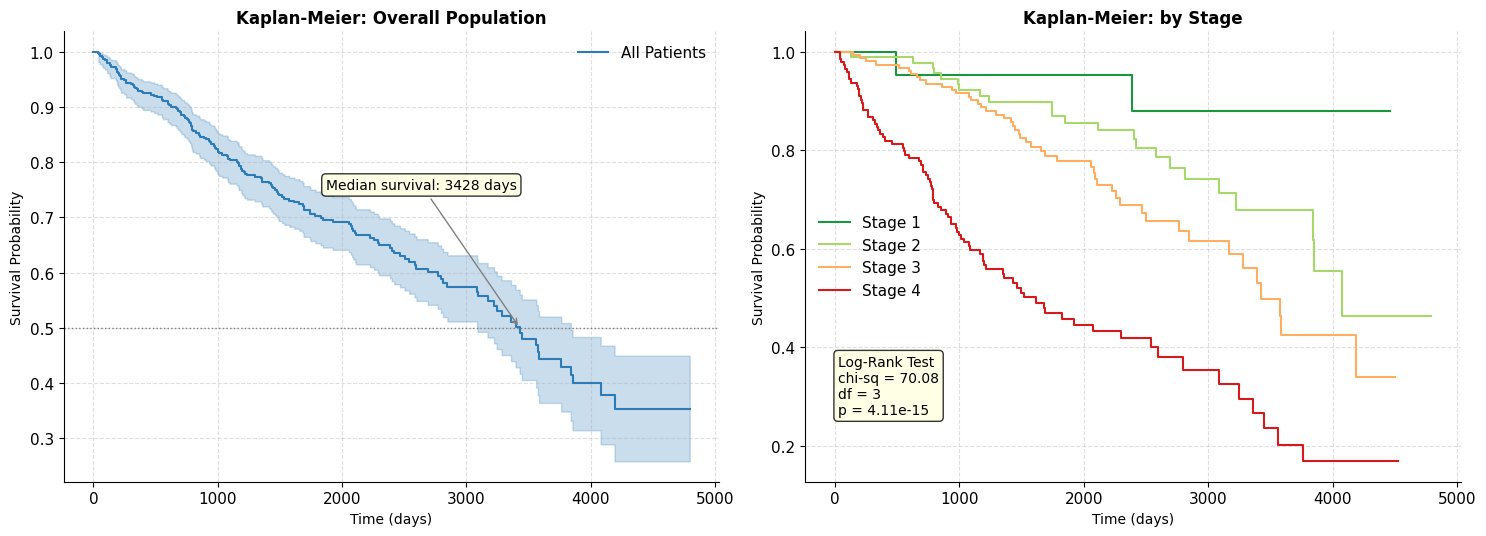

In [5]:
# 3: KAPLAN-MEIER ANALYSIS

def fit_kaplan_meier_overall(
    df: pd.DataFrame,
    config: PipelineConfig,
) -> KaplanMeierFitter:
    """Fit Kaplan-Meier estimator untuk keseluruhan populasi."""
    kmf = KaplanMeierFitter()
    kmf.fit(
        durations=df[config.duration_col],
        event_observed=df[config.event_col],
        label="All Patients",
    )
    return kmf


def fit_kaplan_meier_by_group(
    df: pd.DataFrame,
    group_col: str,
    config: PipelineConfig,
) -> Dict[float, KaplanMeierFitter]:
    """Fit KM per grup berdasarkan group_col."""
    fitters: Dict[float, KaplanMeierFitter] = {}
    for group_val in sorted(df[group_col].unique()):
        mask = df[group_col] == group_val
        kmf = KaplanMeierFitter()
        kmf.fit(
            durations=df.loc[mask, config.duration_col],
            event_observed=df.loc[mask, config.event_col],
            label=f"{group_col.capitalize()} {int(group_val)}",
        )
        fitters[group_val] = kmf
    return fitters


def run_logrank_test(
    df: pd.DataFrame,
    group_col: str,
    config: PipelineConfig,
) -> Dict[str, float]:
    """
    Jalankan multivariate log-rank test antar level group_col.

    Returns
    -------
    dict
        {"test_statistic": float, "p_value": float, "significant": bool, "df": int}
    """
    result = multivariate_logrank_test(
        event_durations=df[config.duration_col],
        groups=df[group_col],
        event_observed=df[config.event_col],
    )
    return {
        "test_statistic": float(result.test_statistic),
        "p_value":        float(result.p_value),
        "significant":    bool(result.p_value < config.alpha),
        "df":             int(result.degrees_of_freedom),
    }


def plot_kaplan_meier(
    kmf_overall: KaplanMeierFitter,
    kmf_by_group: Dict[float, KaplanMeierFitter],
    group_col: str,
    logrank: Dict[str, float],
) -> None:
    """Plot KM overall + KM stratified by group dalam satu figure."""
    fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

    # Panel 1: KM overall
    kmf_overall.plot_survival_function(ax=axes[0], ci_show=True, color="#2c7bb6")
    median_surv = kmf_overall.median_survival_time_
    axes[0].axhline(0.5, color="gray", linestyle=":", linewidth=1)
    axes[0].set_title("Kaplan-Meier: Overall Population")
    axes[0].set_xlabel("Time (days)")
    axes[0].set_ylabel("Survival Probability")
    if not np.isinf(median_surv):
        axes[0].annotate(
            f"Median survival: {median_surv:.0f} days",
            xy=(median_surv, 0.5),
            xytext=(0.4, 0.65),
            textcoords="axes fraction",
            fontsize=10,
            bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8),
            arrowprops=dict(arrowstyle="->", color="gray"),
        )

    # Panel 2: KM by stage
    stage_palette = {1: "#1a9641", 2: "#a6d96a", 3: "#fdae61", 4: "#d7191c"}
    for group_val, kmf in kmf_by_group.items():
        color = stage_palette.get(int(group_val), "black")
        kmf.plot_survival_function(ax=axes[1], ci_show=False, color=color)
    axes[1].set_title(f"Kaplan-Meier: by {group_col.capitalize()}")
    axes[1].set_xlabel("Time (days)")
    axes[1].set_ylabel("Survival Probability")
    axes[1].text(
        0.05, 0.15,
        f"Log-Rank Test\nchi-sq = {logrank['test_statistic']:.2f}\n"
        f"df = {logrank['df']}\np = {logrank['p_value']:.2e}",
        transform=axes[1].transAxes,
        fontsize=10,
        bbox=dict(boxstyle="round", facecolor="lightyellow", alpha=0.8),
    )

    plt.tight_layout()
    plt.show()


# Jalankan analisis KM
kmf_all = fit_kaplan_meier_overall(df_survival, CONFIG)
kmf_by_stage = fit_kaplan_meier_by_group(
    df_survival, CONFIG.ph_violating_var, CONFIG
)
logrank_result = run_logrank_test(
    df_survival, CONFIG.ph_violating_var, CONFIG
)

# Print summary
print("=" * 70)
print("KAPLAN-MEIER & LOG-RANK TEST")
print("=" * 70)
print(f"Median survival (overall): {kmf_all.median_survival_time_:.0f} days")
print()
print(f"Log-Rank Test (antar {CONFIG.ph_violating_var}):")
print(f"  Test statistic : {logrank_result['test_statistic']:.4f}")
print(f"  Degrees of fr. : {logrank_result['df']}")
print(f"  p-value        : {logrank_result['p_value']:.2e}")
print(f"  Significant    : {logrank_result['significant']} "
      f"(alpha = {CONFIG.alpha})")

# Plot
plot_kaplan_meier(kmf_all, kmf_by_stage, CONFIG.ph_violating_var, logrank_result)


## 6. Stage 4: Standard Cox Proportional Hazard Model

Model baseline. Dipakai sebagai titik perbandingan dan untuk menguji apakah
asumsi PH dipenuhi.

**Asumsi**: hazard ratio antar individu konstan terhadap waktu (proporsional).


In [6]:
# 4: STANDARD COX PROPORTIONAL HAZARD MODEL

def fit_standard_cox(
    df: pd.DataFrame,
    config: PipelineConfig,
    robust: bool = False,
) -> CoxPHFitter:
    """
    Fit Standard Cox PH Model.

    Parameters
    ----------
    df : pd.DataFrame
        Dataset dengan kolom duration, event, dan covariates
    config : PipelineConfig
    robust : bool
        Gunakan sandwich (robust) variance estimator untuk SE.
        Default False - sesuai konvensi survival analysis. Set True jika
        ada kekhawatiran tentang clustering atau model misspecification.

    Returns
    -------
    CoxPHFitter
        Model yang sudah difit. Akses summary lewat .summary
    """
    cph = CoxPHFitter(baseline_estimation_method="breslow")
    cph.fit(
        df,
        duration_col=config.duration_col,
        event_col=config.event_col,
        robust=robust,
    )
    return cph


def print_cox_summary(model: CoxPHFitter, model_name: str) -> None:
    """Print Cox model summary dalam format tabel yang rapi."""
    summary = model.summary[[
        "coef", "exp(coef)", "se(coef)",
        "exp(coef) lower 95%", "exp(coef) upper 95%", "p",
    ]].rename(columns={
        "coef":                "beta",
        "exp(coef)":           "HR",
        "se(coef)":            "SE",
        "exp(coef) lower 95%": "HR_low",
        "exp(coef) upper 95%": "HR_high",
        "p":                   "p_value",
    }).round(4)

    print("=" * 70)
    print(f"{model_name.upper()}")
    print("=" * 70)
    print(summary.to_string())
    print()
    print(f"Concordance Index : {model.concordance_index_:.4f}")
    print(f"AIC (Partial)     : {model.AIC_partial_:.4f}")
    print(f"Log-likelihood    : {model.log_likelihood_:.4f}")


cph_standard = fit_standard_cox(df_survival, CONFIG)
print_cox_summary(cph_standard, "Standard Cox PH Model")


STANDARD COX PH MODEL
             beta      HR      SE  HR_low  HR_high  p_value
covariate                                                  
age        0.0316  1.0321  0.0082  1.0156   1.0489   0.0001
bili       0.1335  1.1428  0.0128  1.1145   1.1718   0.0000
albumin   -0.9863  0.3729  0.2082  0.2480   0.5609   0.0000
stage      0.5427  1.7207  0.1130  1.3787   2.1474   0.0000

Concordance Index : 0.8178
AIC (Partial)     : 1517.0507
Log-likelihood    : -754.5253


## 7. Stage 5: Proportional Hazard Assumption Test

**Schoenfeld Residual Test**:
- H0: variabel memenuhi asumsi PH (residual independen terhadap waktu)
- H1: efek variabel berubah terhadap waktu (PH dilanggar)

**Time transform**: `rank` (default, robust) - mengurangi influence outlier waktu.

Hasil uji menentukan jalur model selanjutnya:
- Semua variabel PASS -> lanjut dengan Standard Cox
- Ada yang FAIL -> butuh Stratified Cox atau Extended Cox


PROPORTIONAL HAZARD ASSUMPTION TEST (Schoenfeld)
         chi_squared  p_value  violated
age           0.1443   0.7040     False
albumin       1.1763   0.2781     False
bili          1.2784   0.2582     False
stage         4.0656   0.0438      True

RESULT: PH ASSUMPTION VIOLATED on: ['stage']
=> Lanjut ke Stratified Cox dan Extended Cox sebagai alternatif


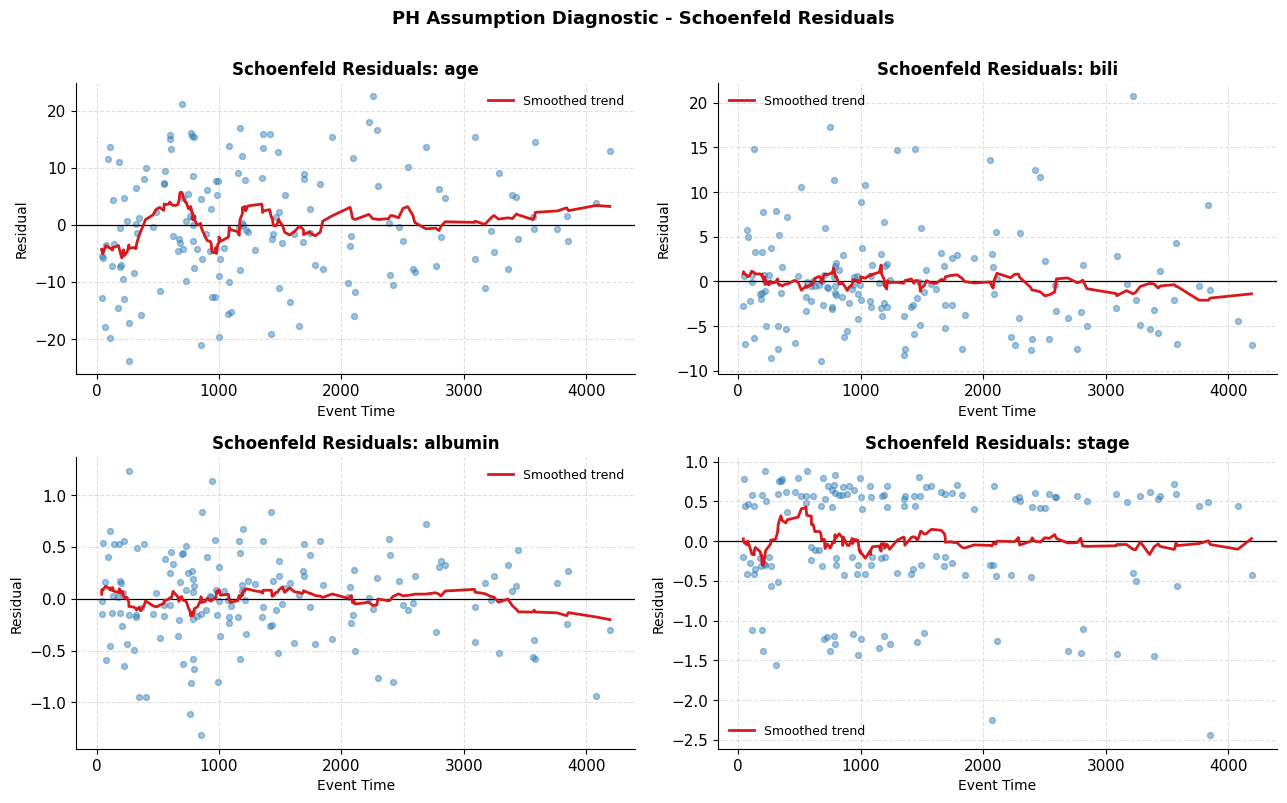

In [7]:
# 5: PH ASSUMPTION TEST (SCHOENFELD RESIDUALS)

def test_ph_assumption(
    model: CoxPHFitter,
    df: pd.DataFrame,
    config: PipelineConfig,
    time_transform: str = "rank",
) -> Dict[str, object]:
    """
    Uji asumsi proportional hazard dengan Schoenfeld residual test.

    Returns
    -------
    dict
        - "summary"       : pd.DataFrame dengan test_statistic, p_value, violated
        - "violated_vars" : list variabel yang melanggar PH
        - "any_violation" : bool, True jika minimal satu variabel melanggar
    """
    test = proportional_hazard_test(
        model, df, time_transform=time_transform
    )
    summary = test.summary.copy()
    summary["violated"] = summary["p"] < config.alpha
    summary = summary[["test_statistic", "p", "violated"]].rename(columns={
        "test_statistic": "chi_squared",
        "p":              "p_value",
    }).round(4)

    violated_vars = summary.index[summary["violated"]].tolist()

    return {
        "summary":       summary,
        "violated_vars": violated_vars,
        "any_violation": len(violated_vars) > 0,
    }


def plot_schoenfeld_residuals(
    model: CoxPHFitter,
    df: pd.DataFrame,
    config: PipelineConfig,
) -> None:
    """
    Plot Schoenfeld residuals per kovariat dengan smoothed trend line.
    Tren non-horizontal menandakan pelanggaran asumsi PH.
    """
    covariates = list(model.params_.index)
    n_cov = len(covariates)
    n_cols = 2
    n_rows = (n_cov + 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(13, 4 * n_rows))
    axes = axes.flatten() if n_cov > 1 else [axes]

    residuals = model.compute_residuals(df, kind="schoenfeld")
    event_times = df.loc[df[config.event_col] == 1, config.duration_col].values

    for i, cov in enumerate(covariates):
        ax = axes[i]
        ax.scatter(event_times, residuals[cov], alpha=0.45, s=18, color="#2c7bb6")
        ax.axhline(0, color="black", linewidth=0.9)

        # Rolling-mean smoother
        sorted_idx = np.argsort(event_times)
        x_sorted = event_times[sorted_idx]
        y_sorted = residuals[cov].values[sorted_idx]
        window = max(15, len(x_sorted) // 8)
        y_smooth = pd.Series(y_sorted).rolling(
            window, center=True, min_periods=5
        ).mean()
        ax.plot(x_sorted, y_smooth, color="#d7191c", linewidth=2.0,
                label="Smoothed trend")

        ax.set_title(f"Schoenfeld Residuals: {cov}")
        ax.set_xlabel("Event Time")
        ax.set_ylabel("Residual")
        ax.legend(fontsize=9, loc="best")

    # Hide unused axes
    for j in range(n_cov, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle(
        "PH Assumption Diagnostic - Schoenfeld Residuals",
        fontsize=13, fontweight="bold", y=1.00,
    )
    plt.tight_layout()
    plt.show()


# Jalankan PH test
ph_test_result = test_ph_assumption(cph_standard, df_survival, CONFIG)

print("=" * 70)
print("PROPORTIONAL HAZARD ASSUMPTION TEST (Schoenfeld)")
print("=" * 70)
print(ph_test_result["summary"].to_string())
print()
if ph_test_result["any_violation"]:
    print(f"RESULT: PH ASSUMPTION VIOLATED on: {ph_test_result['violated_vars']}")
    print("=> Lanjut ke Stratified Cox dan Extended Cox sebagai alternatif")
else:
    print("RESULT: All variables satisfy PH assumption")
    print("=> Standard Cox dapat digunakan sebagai model final")

# Plot residuals
plot_schoenfeld_residuals(cph_standard, df_survival, CONFIG)


## 8. Stage 6: Stratified Cox Model

**Strategi**: variabel yang melanggar PH dipindahkan dari covariate ke **strata**.
Setiap strata memiliki baseline hazard sendiri sehingga asumsi PH untuk variabel
tersebut tidak lagi diperlukan.

**Trade-off**:
- (+) Mengatasi PH violation dengan asumsi yang sangat lemah
- (-) Tidak menghasilkan Hazard Ratio untuk variabel strata


In [8]:
# 6: STRATIFIED COX MODEL

def fit_stratified_cox(
    df: pd.DataFrame,
    config: PipelineConfig,
    robust: bool = False,
) -> CoxPHFitter:
    """
    Fit Stratified Cox dengan ph_violating_var sebagai strata.

    Catatan: AIC partial dari Stratified Cox tidak dapat dibandingkan
    langsung dengan AIC partial dari Standard/Extended Cox karena
    menggunakan basis stratified partial likelihood yang berbeda.
    """
    cph = CoxPHFitter(baseline_estimation_method="breslow")
    cph.fit(
        df,
        duration_col=config.duration_col,
        event_col=config.event_col,
        strata=[config.ph_violating_var],
        robust=robust,
    )
    return cph


cph_stratified = fit_stratified_cox(df_survival, CONFIG)
print_cox_summary(cph_stratified, f"Stratified Cox Model (strata: {CONFIG.ph_violating_var})")
print()
print("CAVEAT: AIC partial stratified TIDAK sebanding dengan AIC partial")
print("standard/extended Cox karena menggunakan stratified partial likelihood.")


STRATIFIED COX MODEL (STRATA: STAGE)
             beta      HR      SE  HR_low  HR_high  p_value
covariate                                                  
age        0.0310  1.0315  0.0082  1.0150   1.0483   0.0002
bili       0.1430  1.1537  0.0140  1.1225   1.1858   0.0000
albumin   -0.9026  0.4055  0.2090  0.2692   0.6108   0.0000

Concordance Index : 0.7596
AIC (Partial)     : 1205.8681
Log-likelihood    : -599.9341

CAVEAT: AIC partial stratified TIDAK sebanding dengan AIC partial
standard/extended Cox karena menggunakan stratified partial likelihood.


## 9. Stage 7: Extended Cox Model (Time-Varying Coefficient)

**Strategi**: tambahkan interaksi `stage x log(t)` untuk memodelkan efek
yang berubah terhadap waktu secara eksplisit.

**Metodologi (PENTING)**:
- Pendekatan ini mensyaratkan **long-format** (start-stop) data, di mana setiap
  subjek dipecah menjadi beberapa interval waktu.
- Pada setiap interval, time-varying covariate dievaluasi pada waktu di interval
  tersebut, bukan pada event time subjek itu sendiri.
- Pendekatan naive `stage * log(event_time_i)` di banyak tutorial menyebabkan
  **data leakage** dan inflated concordance - dihindari di sini.
- Time-varying covariate: `stage_x_logt = stage * (log(t) - mean_log_t)`
  Centering meningkatkan stabilitas numerik dan interpretasi.

**Implementasi**: `CoxTimeVaryingFitter` dengan partial likelihood pada long-format.


In [9]:
# 7: EXTENDED COX MODEL (TIME-VARYING COEFFICIENT)

def build_long_format_data(
    df: pd.DataFrame,
    config: PipelineConfig,
    n_intervals: int = 4,
) -> Tuple[pd.DataFrame, float]:
    """
    Konversi short-format ke long-format untuk time-varying covariate fitting.

    Setiap subjek dipecah menjadi beberapa interval [start, stop] berdasarkan
    breakpoints common (kuantil dari event times). Pada setiap interval,
    time-varying covariate dievaluasi di MIDPOINT interval - bukan di event time.

    Parameters
    ----------
    df : pd.DataFrame
        Short-format data
    config : PipelineConfig
    n_intervals : int
        Jumlah interval (default 4 -> breakpoints di 25%, 50%, 75% event times)

    Returns
    -------
    df_long : pd.DataFrame
        Long-format dengan kolom: id, start, stop, event, [covariates], stage_x_logt
    mean_logt : float
        Mean dari log midpoint times (untuk centering, disimpan untuk reference)
    """
    df = df.copy()
    df["_id"] = df.index

    # Breakpoints: kuantil dari event times
    event_times = df.loc[df[config.event_col] == 1, config.duration_col].values
    quantile_points = np.linspace(0, 1, n_intervals + 1)[1:-1]
    breakpoints = np.unique(np.quantile(event_times, quantile_points))

    rows = []
    for _, r in df.iterrows():
        T_i = r[config.duration_col]
        E_i = int(r[config.event_col])
        prev = 0.0
        # Intervals sebelum event/censor time
        for bp in breakpoints:
            if bp >= T_i:
                break
            row_dict = {
                "id": int(r["_id"]),
                "start": prev,
                "stop": float(bp),
                "event": 0,
                "_logt_mid": np.log((prev + bp) / 2 + 1.0),
            }
            for cov in config.covariates:
                row_dict[cov] = r[cov]
            rows.append(row_dict)
            prev = float(bp)
        # Final interval (mengandung event/censor)
        row_dict = {
            "id": int(r["_id"]),
            "start": prev,
            "stop": T_i,
            "event": E_i,
            "_logt_mid": np.log((prev + T_i) / 2 + 1.0),
        }
        for cov in config.covariates:
            row_dict[cov] = r[cov]
        rows.append(row_dict)

    df_long = pd.DataFrame(rows)
    mean_logt = df_long["_logt_mid"].mean()

    # Time-varying interaction (centered untuk stabilitas)
    df_long[f"{config.ph_violating_var}_x_logt"] = (
        df_long[config.ph_violating_var]
        * (df_long["_logt_mid"] - mean_logt)
    )
    df_long = df_long.drop(columns=["_logt_mid"])

    # Sanity check: jumlah event harus sama
    assert df_long["event"].sum() == df[config.event_col].sum(), \
        "Jumlah event di long-format harus sama dengan original"

    return df_long, mean_logt


def fit_extended_cox(
    df_long: pd.DataFrame,
    config: PipelineConfig,
    penalizer: float = 0.0,
) -> CoxTimeVaryingFitter:
    """
    Fit Extended Cox (CoxTimeVaryingFitter) pada long-format data.

    Jika tidak konvergen tanpa penalizer, increment penalizer sampai konvergen.
    """
    for pen in [penalizer, 0.01, 0.05, 0.1]:
        try:
            model = CoxTimeVaryingFitter(penalizer=pen)
            model.fit(
                df_long,
                id_col="id",
                start_col="start",
                stop_col="stop",
                event_col="event",
                show_progress=False,
            )
            if pen > 0:
                print(f"  (Konvergen dengan penalizer={pen})")
            return model
        except Exception:
            continue
    raise RuntimeError("Extended Cox tidak konvergen di semua level penalizer")


def print_extended_cox_summary(
    model: CoxTimeVaryingFitter,
    model_name: str = "Extended Cox Model",
) -> None:
    """Print summary untuk CoxTimeVaryingFitter (yang tidak punya AIC_partial_)."""
    summary = model.summary[[
        "coef", "exp(coef)", "se(coef)",
        "exp(coef) lower 95%", "exp(coef) upper 95%", "p",
    ]].rename(columns={
        "coef":                "beta",
        "exp(coef)":           "HR",
        "se(coef)":            "SE",
        "exp(coef) lower 95%": "HR_low",
        "exp(coef) upper 95%": "HR_high",
        "p":                   "p_value",
    }).round(4)

    k = len(model.params_)
    aic = 2 * k - 2 * model.log_likelihood_

    print("=" * 70)
    print(model_name.upper())
    print("=" * 70)
    print(summary.to_string())
    print()
    print(f"Log-likelihood : {model.log_likelihood_:.4f}")
    print(f"# Parameters   : {k}")
    print(f"AIC            : {aic:.4f}")
    print()
    print("Note: Concordance tidak dilaporkan untuk model time-varying karena")
    print("tidak well-defined tanpa evaluasi pada waktu tertentu.")


# Build long-format dan fit
df_long, _ = build_long_format_data(df_survival, CONFIG, n_intervals=4)
print(f"Long-format dataset: {len(df_long)} rows dari {df_survival.shape[0]} subjek")
print(f"Average rows per subject: {len(df_long) / df_survival.shape[0]:.1f}")
print()

cph_extended = fit_extended_cox(df_long, CONFIG)
print_extended_cox_summary(cph_extended)

# Compute AIC untuk perbandingan
EXTENDED_AIC = 2 * len(cph_extended.params_) - 2 * cph_extended.log_likelihood_


Long-format dataset: 1264 rows dari 412 subjek
Average rows per subject: 3.1

EXTENDED COX MODEL
                beta      HR      SE  HR_low  HR_high  p_value
covariate                                                     
age           0.0243  1.0246  0.0084  1.0079   1.0415   0.0037
bili          0.1063  1.1121  0.0169  1.0758   1.1496   0.0000
albumin      -0.4317  0.6494  0.2208  0.4213   1.0011   0.0506
stage         2.0523  7.7861  0.2143  5.1155  11.8509   0.0000
stage_x_logt -2.1581  0.1155  0.1933  0.0791   0.1688   0.0000

Log-likelihood : -615.2985
# Parameters   : 5
AIC            : 1240.5969

Note: Concordance tidak dilaporkan untuk model time-varying karena
tidak well-defined tanpa evaluasi pada waktu tertentu.


## 10. Stage 8: Model Comparison & Selection

Kriteria perbandingan (dari paling penting ke paling pelengkap):

1. **Kepatuhan asumsi PH** - model yang melanggar asumsi statistik harus didiskualifikasi
2. **AIC** - hanya valid untuk Standard vs Extended Cox (basis likelihood yang sama)
3. **Concordance Index** - tidak dilaporkan untuk Extended Cox (time-varying)
4. **Interpretabilitas klinis** - apakah HR pada variabel kunci tersedia?


In [10]:
# 8: MODEL COMPARISON & SELECTION

def compare_models(
    standard: CoxPHFitter,
    stratified: CoxPHFitter,
    extended: CoxTimeVaryingFitter,
    ph_test: Dict[str, object],
    config: PipelineConfig,
) -> Tuple[pd.DataFrame, str]:
    """
    Bandingkan ketiga model dan tentukan model final berdasarkan multi-kriteria.

    Aturan keputusan:
    1. Jika ada model yang melanggar PH, didiskualifikasi sebagai final model
    2. Di antara yang tidak melanggar, pilih berdasarkan:
       - AIC terkecil (jika comparable)
       - Interpretabilitas (preferensi pada model yang menyediakan HR variabel kunci)

    Returns
    -------
    comparison_df : pd.DataFrame
        Tabel perbandingan model
    selected : str
        Nama model terpilih
    """
    ph_violated = ph_test["any_violation"]
    violated_vars = ph_test["violated_vars"]

    extended_aic = 2 * len(extended.params_) - 2 * extended.log_likelihood_

    comparison = pd.DataFrame([
        {
            "Model":              "Standard Cox",
            "Log-likelihood":     round(standard.log_likelihood_, 4),
            "AIC":                round(standard.AIC_partial_, 4),
            "Concordance":        round(standard.concordance_index_, 4),
            "PH Satisfied":       not ph_violated,
            "HR for stage":       "Yes",
            "Note": ("PH violated on " + ",".join(violated_vars)
                     if ph_violated else "PH OK"),
        },
        {
            "Model":              "Stratified Cox",
            "Log-likelihood":     round(stratified.log_likelihood_, 4),
            "AIC":                "N/A (stratified)",
            "Concordance":        round(stratified.concordance_index_, 4),
            "PH Satisfied":       True,
            "HR for stage":       "No (stratified out)",
            "Note":               "AIC tidak comparable",
        },
        {
            "Model":              "Extended Cox",
            "Log-likelihood":     round(extended.log_likelihood_, 4),
            "AIC":                round(extended_aic, 4),
            "Concordance":        "N/A (time-varying)",
            "PH Satisfied":       True,
            "HR for stage":       "Yes (time-varying)",
            "Note":               "Modeled time-varying effect",
        },
    ]).set_index("Model")

    # Decision logic
    # Kandidat: model yang tidak melanggar PH
    if ph_violated:
        # Antara Stratified dan Extended: pilih Extended jika AIC vs Standard
        # menunjukkan improvement signifikan (delta AIC > 10)
        delta_aic = standard.AIC_partial_ - extended_aic
        if delta_aic > 10:
            selected = "Extended Cox"
            reason = (
                f"PH violation pada {violated_vars}; Extended Cox menunjukkan "
                f"improvement AIC signifikan vs Standard Cox (delta = {delta_aic:.2f})"
            )
        else:
            selected = "Stratified Cox"
            reason = (
                f"PH violation pada {violated_vars}; Extended Cox tidak menunjukkan "
                f"improvement AIC signifikan -> pilih Stratified untuk parsimony"
            )
    else:
        selected = "Standard Cox"
        reason = "Semua asumsi terpenuhi"

    return comparison, selected, reason


comparison_df, selected_model_name, selection_reason = compare_models(
    cph_standard, cph_stratified, cph_extended,
    ph_test_result, CONFIG,
)

print("=" * 75)
print("MODEL COMPARISON")
print("=" * 75)
print(comparison_df.to_string())
print()
print("=" * 75)
print(f"SELECTED MODEL: {selected_model_name}")
print("=" * 75)
print(f"Reason: {selection_reason}")


MODEL COMPARISON
                Log-likelihood               AIC         Concordance  PH Satisfied         HR for stage                         Note
Model                                                                                                                               
Standard Cox         -754.5253         1517.0507              0.8178         False                  Yes         PH violated on stage
Stratified Cox       -599.9341  N/A (stratified)              0.7596          True  No (stratified out)         AIC tidak comparable
Extended Cox         -615.2985         1240.5969  N/A (time-varying)          True   Yes (time-varying)  Modeled time-varying effect

SELECTED MODEL: Extended Cox
Reason: PH violation pada ['stage']; Extended Cox menunjukkan improvement AIC signifikan vs Standard Cox (delta = 276.45)


## 11. Stage 9: Final Model Interpretation

Hazard Ratio (HR) interpretation:
- **HR > 1**: variabel meningkatkan risiko event (kematian)
- **HR < 1**: variabel menurunkan risiko event (protektif)
- **HR = 1**: variabel tidak berpengaruh

95% Confidence Interval yang tidak mencakup 1 menandakan signifikansi statistik.


INTERPRETATION: EXTENDED COX

age
  HR (95% CI) : 1.0246 (1.0079 - 1.0415)
  p-value     : 0.0037  [SIGNIFICANT]
  Effect      : meningkatkan risiko sebesar 2.5% per unit

bili
  HR (95% CI) : 1.1121 (1.0758 - 1.1496)
  p-value     : 0.0000  [SIGNIFICANT]
  Effect      : meningkatkan risiko sebesar 11.2% per unit

albumin
  HR (95% CI) : 0.6494 (0.4213 - 1.0011)
  p-value     : 0.0506  [Not significant]
  Effect      : menurunkan risiko sebesar 35.1% per unit

stage
  HR (95% CI) : 7.7861 (5.1155 - 11.8509)
  p-value     : 0.0000  [SIGNIFICANT]
  Effect      : meningkatkan risiko sebesar 678.6% per unit

stage_x_logt
  HR (95% CI) : 0.1155 (0.0791 - 0.1688)
  p-value     : 0.0000  [SIGNIFICANT]
  Effect      : menurunkan risiko sebesar 88.4% per unit
  Note        : Interaksi time-varying. exp(coef)=0.1155<1 berarti
                efek 'stage' menurun seiring bertambahnya log(t).
                HR 'stage' di atas berlaku pada centered baseline time.



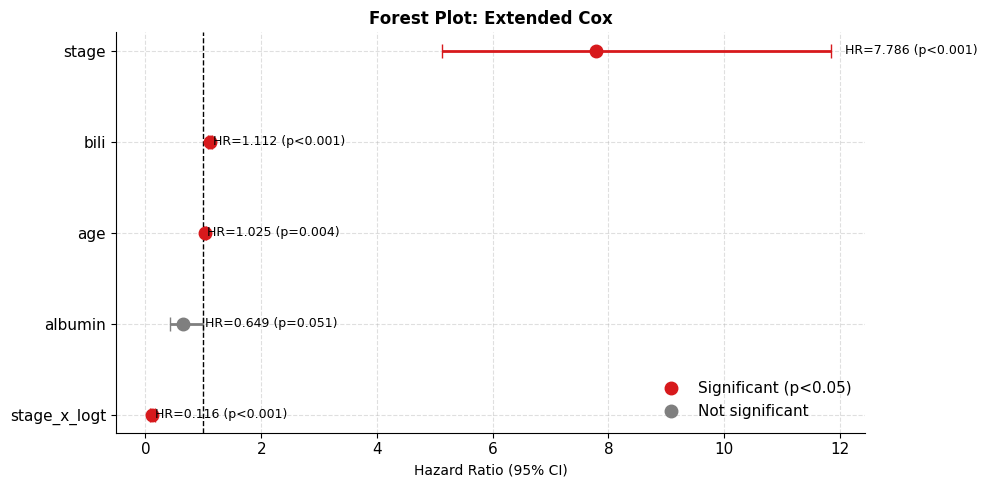

In [11]:
# 9: FINAL MODEL INTERPRETATION

# Pilih model final
MODELS = {
    "Standard Cox":   cph_standard,
    "Stratified Cox": cph_stratified,
    "Extended Cox":   cph_extended,
}
final_model = MODELS[selected_model_name]


def interpret_hazard_ratios(
    model,
    model_name: str,
    config: PipelineConfig,
) -> None:
    """Cetak interpretasi klinis tiap koefisien dari model final."""
    summary = model.summary

    print("=" * 75)
    print(f"INTERPRETATION: {model_name.upper()}")
    print("=" * 75)

    for var, row in summary.iterrows():
        hr = row["exp(coef)"]
        ci_low = row["exp(coef) lower 95%"]
        ci_high = row["exp(coef) upper 95%"]
        p_val = row["p"]
        is_sig = p_val < config.alpha

        if hr > 1:
            direction = f"meningkatkan risiko sebesar {(hr - 1) * 100:.1f}% per unit"
        elif hr < 1:
            direction = f"menurunkan risiko sebesar {(1 - hr) * 100:.1f}% per unit"
        else:
            direction = "tidak mengubah risiko"

        sig_label = "SIGNIFICANT" if is_sig else "Not significant"

        print(f"\n{var}")
        print(f"  HR (95% CI) : {hr:.4f} ({ci_low:.4f} - {ci_high:.4f})")
        print(f"  p-value     : {p_val:.4f}  [{sig_label}]")
        print(f"  Effect      : {direction}")
        if "_x_logt" in var:
            base_var = var.replace("_x_logt", "")
            direction = "menurun" if hr < 1 else "meningkat"
            print(f"  Note        : Interaksi time-varying. exp(coef)={hr:.4f}<1 berarti")
            print(f"                efek '{base_var}' {direction} seiring bertambahnya log(t).")
            print(f"                HR '{base_var}' di atas berlaku pada centered baseline time.")


def plot_forest(
    model,
    model_name: str,
    config: PipelineConfig,
) -> None:
    """Forest plot Hazard Ratios dengan 95% CI."""
    summary = model.summary[[
        "exp(coef)", "exp(coef) lower 95%", "exp(coef) upper 95%", "p",
    ]].copy()
    summary.columns = ["HR", "CI_low", "CI_high", "p"]
    summary["sig"] = summary["p"] < config.alpha
    summary = summary.sort_values("HR")

    fig, ax = plt.subplots(figsize=(10, max(3, len(summary) * 1.0)))

    for i, (var, row) in enumerate(summary.iterrows()):
        color = "#d7191c" if row["sig"] else "#7f7f7f"
        ax.errorbar(
            x=row["HR"], y=i,
            xerr=[[max(row["HR"] - row["CI_low"], 0)],
                  [max(row["CI_high"] - row["HR"], 0)]],
            fmt="o", color=color, markersize=9, capsize=5, linewidth=2,
        )
        p_str = f"p={row['p']:.3f}" if row["p"] >= 0.001 else "p<0.001"
        ax.text(
            row["CI_high"] * 1.02, i,
            f"HR={row['HR']:.3f} ({p_str})",
            va="center", fontsize=9,
        )

    ax.axvline(x=1, color="black", linestyle="--", linewidth=1)
    ax.set_yticks(range(len(summary)))
    ax.set_yticklabels(summary.index)
    ax.set_xlabel("Hazard Ratio (95% CI)")
    ax.set_title(f"Forest Plot: {model_name}")

    legend_elements = [
        Line2D([0], [0], marker="o", color="#d7191c",
               label=f"Significant (p<{config.alpha})", markersize=9, linestyle=""),
        Line2D([0], [0], marker="o", color="#7f7f7f",
               label="Not significant", markersize=9, linestyle=""),
    ]
    ax.legend(handles=legend_elements, loc="best")
    plt.tight_layout()
    plt.show()


interpret_hazard_ratios(final_model, selected_model_name, CONFIG)
print()
plot_forest(final_model, selected_model_name, CONFIG)


## 12. Conclusion

Ringkasan eksekutif penelitian.


In [12]:
# ============================================================================
# CONCLUSION
# ============================================================================

def print_conclusion(
    df: pd.DataFrame,
    ph_test: Dict[str, object],
    logrank: Dict[str, float],
    selected: str,
    final_model,
    config: PipelineConfig,
) -> None:
    """Print final research conclusion."""
    n_total = len(df)
    n_events = df[config.event_col].sum()
    event_rate = df[config.event_col].mean()

    summary = final_model.summary
    significant_vars = summary.index[summary["p"] < config.alpha].tolist()

    print("=" * 75)
    print("RESEARCH CONCLUSION")
    print("=" * 75)
    print()
    print("Sample characteristics:")
    print(f"  - Total patients     : {n_total}")
    print(f"  - Deaths (events)    : {n_events}")
    print(f"  - Event rate         : {event_rate:.1%}")
    print()
    print("Non-parametric analysis:")
    print(f"  - Log-rank test antar {config.ph_violating_var}: "
          f"chi-sq={logrank['test_statistic']:.2f}, p={logrank['p_value']:.2e}")
    print(f"    -> Survival curves berbeda signifikan antar level "
          f"{config.ph_violating_var}")
    print()
    print("PH assumption test:")
    if ph_test["any_violation"]:
        print(f"  - PH violation pada: {ph_test['violated_vars']}")
        print(f"  -> Standard Cox tidak valid; gunakan Stratified atau Extended Cox")
    else:
        print(f"  - PH assumption terpenuhi untuk semua variabel")
    print()
    print("Final model:")
    print(f"  - Selected      : {selected}")
    print(f"  - Significant variables ({len(significant_vars)}): {significant_vars}")
    print()
    print("Significant prognostic factors:")
    for var in significant_vars:
        hr = summary.loc[var, "exp(coef)"]
        ci_low = summary.loc[var, "exp(coef) lower 95%"]
        ci_high = summary.loc[var, "exp(coef) upper 95%"]
        effect = "increases" if hr > 1 else "decreases"
        print(f"  - {var}: HR={hr:.3f} (95% CI: {ci_low:.3f}-{ci_high:.3f}) "
              f"-> {effect} mortality risk")


print_conclusion(
    df_survival, ph_test_result, logrank_result,
    selected_model_name, final_model, CONFIG,
)


RESEARCH CONCLUSION

Sample characteristics:
  - Total patients     : 412
  - Deaths (events)    : 157
  - Event rate         : 38.1%

Non-parametric analysis:
  - Log-rank test antar stage: chi-sq=70.08, p=4.11e-15
    -> Survival curves berbeda signifikan antar level stage

PH assumption test:
  - PH violation pada: ['stage']
  -> Standard Cox tidak valid; gunakan Stratified atau Extended Cox

Final model:
  - Selected      : Extended Cox
  - Significant variables (4): ['age', 'bili', 'stage', 'stage_x_logt']

Significant prognostic factors:
  - age: HR=1.025 (95% CI: 1.008-1.042) -> increases mortality risk
  - bili: HR=1.112 (95% CI: 1.076-1.150) -> increases mortality risk
  - stage: HR=7.786 (95% CI: 5.115-11.851) -> increases mortality risk
  - stage_x_logt: HR=0.116 (95% CI: 0.079-0.169) -> decreases mortality risk


## 13. Pipeline Orchestrator

Fungsi `run_full_pipeline()` menjalankan seluruh analisis end-to-end.
Berguna untuk reproducibility - hasil bisa direplikasi dengan satu pemanggilan.


In [14]:
# ============================================================================
# MAIN PIPELINE ORCHESTRATOR
# ============================================================================

def run_full_pipeline(config: PipelineConfig) -> Dict[str, object]:
    """
    Jalankan pipeline survival analysis end-to-end.

    Returns
    -------
    dict
        Dictionary berisi semua artefak penelitian:
        - "data"           : preprocessed DataFrame
        - "desc_stats"     : descriptive statistics
        - "km_overall"     : KaplanMeierFitter overall
        - "km_by_group"    : dict KaplanMeierFitter per group
        - "logrank"        : log-rank test result
        - "models"         : dict of all fitted Cox models
        - "ph_test"        : PH assumption test result
        - "comparison"     : model comparison DataFrame
        - "selected_model" : name of final selected model
        - "final_model"    : the selected model object
    """
    print("\n" + "#" * 75)
    print("# RUNNING FULL PIPELINE")
    print("#" * 75)

    # Stage 1-2: Data
    df = load_and_preprocess(config)
    desc = compute_descriptive_stats(df, config)

    # Stage 3: KM + Log-Rank
    km_all = fit_kaplan_meier_overall(df, config)
    km_grp = fit_kaplan_meier_by_group(df, config.ph_violating_var, config)
    logrank = run_logrank_test(df, config.ph_violating_var, config)

    # Stage 4-5: Standard Cox + PH test
    m_std = fit_standard_cox(df, config)
    ph_test = test_ph_assumption(m_std, df, config)

    # Stage 6: Stratified Cox
    m_strat = fit_stratified_cox(df, config)

    # Stage 7: Extended Cox
    df_long, _ = build_long_format_data(df, config)
    m_ext = fit_extended_cox(df_long, config)

    # Stage 8: Model selection
    comparison_df, selected, reason = compare_models(
        m_std, m_strat, m_ext, ph_test, config,
    )

    models = {
        "Standard Cox":   m_std,
        "Stratified Cox": m_strat,
        "Extended Cox":   m_ext,
    }

    return {
        "data":            df,
        "desc_stats":      desc,
        "km_overall":      km_all,
        "km_by_group":     km_grp,
        "logrank":         logrank,
        "models":          models,
        "ph_test":         ph_test,
        "comparison":      comparison_df,
        "selected_model":  selected,
        "selection_reason": reason,
        "final_model":     models[selected],
    }


# Jalankan pipeline (catatan: cell-cell di atas sudah jalan satu-per-satu,
# fungsi di bawah ini hanya untuk demonstrasi orchestration end-to-end yang
# bisa dipanggil sebagai satu unit untuk reproducibility)

results = run_full_pipeline(CONFIG)
print(f"\nPipeline selesai. Final model: {results['selected_model']}")

# uncomment kode di atas untuk menjalankan seluruh pipeline sekaligus.




###########################################################################
# RUNNING FULL PIPELINE
###########################################################################
[Stage 1] Data loaded
  Rows raw           : 418
  Rows dropped (NaN) : 6
  Rows final         : 412
  Events / Censored  : 157 / 255
  Event rate         : 38.1%
  Follow-up range    : 41 - 4795 hari
DESCRIPTIVE STATISTICS

Summary - Variabel Kontinu:
----------------------------------------------------------------------
         count     mean      std    min      25%      50%      75%      max
time     412.0  1916.84  1099.94  41.00  1094.25  1713.50  2610.50  4795.00
age      412.0    50.65    10.47  26.28    42.74    51.00    58.04    78.44
bili     412.0     3.23     4.43   0.30     0.80     1.40     3.40    28.00
albumin  412.0     3.50     0.42   1.96     3.25     3.53     3.78     4.64

Distribusi Stage:
----------------------------------------------------------------------
           N  Percent
Stage 1